**Loading and balancing the dataset with 10 selected art styles for a total of 11000 images with splits of 80\10\10**

In [1]:
import os
import shutil
import random
import numpy as np
import pandas as pd

from PIL import Image
from sklearn.model_selection import train_test_split


DATASET_PATH = "/kaggle/input/datasets/steubk/wikiart"

OUTPUT_PATH = "/kaggle/working/wikiart_balanced"

MANIFEST_PATH = "/kaggle/working/manifest.csv"
TRAIN_MANIFEST_PATH = "/kaggle/working/train_manifest.csv"
VAL_MANIFEST_PATH = "/kaggle/working/val_manifest.csv"
TEST_MANIFEST_PATH = "/kaggle/working/test_manifest.csv"


TARGET_SIZE = (224,224)

NUM_IMMAGINI_PER_STILE = 1100

SEED = 42

TARGET_STYLES = [
    "Early_Renaissance", 
    "Baroque",
    "Romanticism",
    "Impressionism",
    "Symbolism",
    "Expressionism",
    "Cubism",
    "Ukiyo_e",
    "Abstract_Expressionism",
    "Pop_Art"
]

random.seed(SEED)
np.random.seed(SEED)


if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

os.makedirs(OUTPUT_PATH, exist_ok=True)


records = []


for style in sorted(os.listdir(DATASET_PATH)):

    style_path = os.path.join(DATASET_PATH, style)

    if not os.path.isdir(style_path):
        continue


    for filename in sorted(os.listdir(style_path)):

        if filename.lower().endswith((".jpg",".jpeg",".png")):

            records.append({
                "style": style,
                "filepath": os.path.join(style_path, filename),
                "filename": filename
            })


df = pd.DataFrame(records)


print("Numero immagini disponibili per stile:\n")

style_counts = df["style"].value_counts()


for style in TARGET_STYLES:

    if style in style_counts:

        print(
            f"{style:25s} {style_counts[style]}"
        )

    else:

        print(
            f"{style:25s} NON PRESENTE"
        )

selected_styles = []


for style in TARGET_STYLES:

    if style not in style_counts.index:
        continue


    if style_counts[style] >= NUM_IMMAGINI_PER_STILE:

        selected_styles.append(style)

    else:

        print(
            f"{style} escluso: solo {style_counts[style]} immagini"
        )


print("\nStili selezionati:")
for s in selected_styles:
    print(s)

manifest_rows = []


for style in selected_styles:


    print("\nElaborazione:", style)


    df_style = (
        df[df["style"] == style]
        .sort_values("filename")
        .reset_index(drop=True)
    )


    df_subset = (
        df_style
        .sample(
            n=NUM_IMMAGINI_PER_STILE,
            random_state=SEED
        )
        .sort_values("filename")
    )


    dest_dir = os.path.join(
        OUTPUT_PATH,
        style
    )

    os.makedirs(
        dest_dir,
        exist_ok=True
    )


    for _, row in df_subset.iterrows():

        try:

            with Image.open(row["filepath"]) as img:


                img = img.convert("RGB")

                img = img.resize(
                    TARGET_SIZE,
                    Image.Resampling.LANCZOS
                )


                dest_path = os.path.join(
                    dest_dir,
                    row["filename"]
                )


                img.save(
                    dest_path,
                    "JPEG",
                    quality=90
                )


                manifest_rows.append({

                    "style": style,

                    "filename": row["filename"],

                    "filepath": dest_path

                })


        except Exception:

            continue



manifest_df = (
    pd.DataFrame(manifest_rows)
    .sort_values(
        ["style","filename"]
    )
    .reset_index(drop=True)
)


manifest_df.to_csv(
    MANIFEST_PATH,
    index=False
)


print("\nDataset creato:")
print(
    len(manifest_df),
    "immagini totali"
)


train_parts = []
val_parts = []
test_parts = []


for style in selected_styles:


    df_style = manifest_df[
        manifest_df["style"] == style
    ]

    train, temp = train_test_split(

        df_style,

        test_size=0.20,

        random_state=SEED,

        shuffle=True

    )


    val, test = train_test_split(

        temp,

        test_size=0.50,

        random_state=SEED,

        shuffle=True

    )


    train_parts.append(train)

    val_parts.append(val)

    test_parts.append(test)



train_df = (
    pd.concat(train_parts)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)


val_df = (
    pd.concat(val_parts)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)


test_df = (
    pd.concat(test_parts)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)


train_df.to_csv(
    TRAIN_MANIFEST_PATH,
    index=False
)


val_df.to_csv(
    VAL_MANIFEST_PATH,
    index=False
)


test_df.to_csv(
    TEST_MANIFEST_PATH,
    index=False
)



print("\n==============================")
print("SPLIT DEFINITIVO")
print("==============================")

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)


print("\nFile salvati:")

print(MANIFEST_PATH)

print(TRAIN_MANIFEST_PATH)

print(VAL_MANIFEST_PATH)

print(TEST_MANIFEST_PATH)

Numero immagini disponibili per stile:

Early_Renaissance         1391
Baroque                   4240
Romanticism               7019
Impressionism             13060
Symbolism                 4528
Expressionism             6736
Cubism                    2235
Ukiyo_e                   1167
Abstract_Expressionism    2782
Pop_Art                   1483

Stili selezionati:
Early_Renaissance
Baroque
Romanticism
Impressionism
Symbolism
Expressionism
Cubism
Ukiyo_e
Abstract_Expressionism
Pop_Art

Elaborazione: Early_Renaissance

Elaborazione: Baroque

Elaborazione: Romanticism

Elaborazione: Impressionism

Elaborazione: Symbolism

Elaborazione: Expressionism

Elaborazione: Cubism

Elaborazione: Ukiyo_e

Elaborazione: Abstract_Expressionism

Elaborazione: Pop_Art

Dataset creato:
11000 immagini totali

SPLIT DEFINITIVO
Train: 8800
Validation: 1100
Test: 1100

File salvati:
/kaggle/working/manifest.csv
/kaggle/working/train_manifest.csv
/kaggle/working/val_manifest.csv
/kaggle/working/test_manif

In [ ]:
shutil.make_archive(
    "/kaggle/working/wikiart_balanced",
    "zip",
    OUTPUT_PATH
)

**Creating the dataset divided into test, validation and training set**

In [2]:
import tensorflow as tf
import pandas as pd
import os


TRAIN_MANIFEST_PATH = "/kaggle/working/train_manifest.csv"
VAL_MANIFEST_PATH = "/kaggle/working/val_manifest.csv"
TEST_MANIFEST_PATH = "/kaggle/working/test_manifest.csv"


IMG_SIZE = (224,224)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

train_df = pd.read_csv(TRAIN_MANIFEST_PATH)

val_df = pd.read_csv(VAL_MANIFEST_PATH)

test_df = pd.read_csv(TEST_MANIFEST_PATH)


class_names = sorted(
    train_df["style"].unique()
)


class_to_index = {
    name:index
    for index,name in enumerate(class_names)
}


NUM_CLASSES = len(class_names)



print("Classi:", class_names)

print("Numero classi:", NUM_CLASSES)


def load_image(filepath, label):

    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )


    image = tf.cast(
        image,
        tf.float32
    )


    return image, label


def dataframe_to_dataset(df, shuffle):


    paths = df["filepath"].values


    labels = [
        class_to_index[x]
        for x in df["style"]
    ]


    labels = tf.keras.utils.to_categorical(
        labels,
        num_classes=NUM_CLASSES
    )


    dataset = tf.data.Dataset.from_tensor_slices(
        (
            paths,
            labels
        )
    )


    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )


    if shuffle:

        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42,
            reshuffle_each_iteration=True
        )


    dataset = dataset.batch(
        BATCH_SIZE
    )


    dataset = dataset.prefetch(
        AUTOTUNE
    )


    return dataset


train_ds_base = dataframe_to_dataset(
    train_df,
    shuffle=True
)


val_ds_base = dataframe_to_dataset(
    val_df,
    shuffle=False
)


test_ds_base = dataframe_to_dataset(
    test_df,
    shuffle=False
)



print("\nDataset creati correttamente")

print(
    "Train batch:",
    tf.data.experimental.cardinality(train_ds_base).numpy()
)

print(
    "Validation batch:",
    tf.data.experimental.cardinality(val_ds_base).numpy()
)

print(
    "Test batch:",
    tf.data.experimental.cardinality(test_ds_base).numpy()
)

2026-08-08 11:54:54.136537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786190094.577854      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786190094.703682      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786190095.784655      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786190095.784686      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786190095.784689      58 computation_placer.cc:177] computation placer alr

Classi: ['Abstract_Expressionism', 'Baroque', 'Cubism', 'Early_Renaissance', 'Expressionism', 'Impressionism', 'Pop_Art', 'Romanticism', 'Symbolism', 'Ukiyo_e']
Numero classi: 10


I0000 00:00:1786190115.882245      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786190115.888173      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Dataset creati correttamente
Train batch: 275
Validation batch: 35
Test batch: 35


**Installing Wandb for real-time monitoring of Deep Learning architectures**

In [ ]:
!pip install wandb
import os
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")

os.environ["WANDB_API_KEY"] = wandb_api_key
wandb.login()

**ResNet50V2**

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns
import wandb
from wandb.integration.keras import WandbMetricsLogger
from datetime import datetime

WANDB_PROJECT = "tesi"

base_model_resnet = ResNet50V2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model_resnet.trainable = False

model_resnet = models.Sequential([
    layers.Input(shape=(224,224,3)),

   
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),

    
    layers.Lambda(preprocess_input, name="resnet_preprocess"),
    
   
    base_model_resnet,

    
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
],
name="ResNet50V2_WikiArt"
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**ResNet50V2 training**

In [ ]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy")
    ]
)

early_stop_resnet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

with wandb.init(project=WANDB_PROJECT, name="ResNet50V2_Addestramento"):
   
    history_resnet = model_resnet.fit(
        train_ds_base,
        validation_data=val_ds_base,
        epochs=50,
        callbacks=[
            WandbMetricsLogger(),
            early_stop_resnet
        ]
    )

**ResNet50V2 fine tuning**

In [ ]:
base_model_resnet.trainable = True

for layer in base_model_resnet.layers[:-50]:
    layer.trainable = False

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy")
    ]
)

checkpoint_resnet = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/ResNet50V2_best.keras",
    monitor="val_loss",
    save_best_only=True
)

early_stop_fine_resnet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

with wandb.init(project=WANDB_PROJECT, name="ResNet50V2_FineTuning"):
    history_resnet_fine = model_resnet.fit(
        train_ds_base,
        validation_data=val_ds_base,
        epochs=50,
        callbacks=[
            WandbMetricsLogger(),
            checkpoint_resnet,
            early_stop_fine_resnet
        ]
    )

In [ ]:
model_resnet.save("/kaggle/working/ResNet.keras")
print("ResNet50V2 salvato")

In [ ]:
pd.DataFrame(history_resnet.history).to_csv("/kaggle/working/ResNet50V2_History.csv", index=False)
pd.DataFrame(history_resnet_fine.history).to_csv("/kaggle/working/ResNet50V2_FineTuningHistory.csv", index=False)


test_loss_resnet, test_acc_resnet, test_top2_resnet = model_resnet.evaluate(test_ds_base)

print("\nRISULTATI RESNET")
print("Accuracy:", test_acc_resnet)
print("Top-2:", test_top2_resnet)

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds_base:
    predictions = model_resnet.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

print("ResNet50V2: y_true/y_pred pronti,", len(y_true), "campioni")

**Confusion matrix**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
 
 
def plot_confusion_matrix_with_counts(y_true, y_pred, class_names, title, save_path):

    cm = confusion_matrix(y_true, y_pred)
 
    cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100
 
    annot = np.empty_like(cm).astype(str)
    n_rows, n_cols = cm.shape
    for i in range(n_rows):
        for j in range(n_cols):
            annot[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"
 
    plt.figure(figsize=(16, 14))
 
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"fontsize": 8},
        cbar=True
    )
 
    plt.title(title)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
 
    return cm
 
 
plot_confusion_matrix_with_counts(
    y_true,
    y_pred,
    class_names,
    "Confusion Matrix - ResNet50V2",
    "/kaggle/working/ResNet50V2_CM.jpg"
)

**DenseNet 121**

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns
import wandb
from wandb.integration.keras import WandbMetricsLogger

WANDB_PROJECT = "tesi"


base_model_densenet = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model_densenet.trainable = False

model_densenet = models.Sequential([
    layers.Input(shape=(224,224,3)),

    
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),

    
    layers.Lambda(preprocess_input, name="densenet_preprocess"),

    
    base_model_densenet,

 
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
],
name="DenseNet121_WikiArt"
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**DenseNet121 training**

In [ ]:
model_densenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy")
    ]
)

early_stop_densenet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_densenet = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/DenseNet121_best.keras",
    monitor="val_loss",
    save_best_only=True
)

with wandb.init(project=WANDB_PROJECT, name="DenseNet121_Addestramento"):
   
    history_densenet = model_densenet.fit(
        train_ds_base,
        validation_data=val_ds_base,
        epochs=50,
        callbacks=[
            WandbMetricsLogger(),
            checkpoint_densenet,
            early_stop_densenet
        ]
    )

**DenseNet121 fine tuning**

In [ ]:
base_model_densenet.trainable = True

for layer in base_model_densenet.layers[:-40]:
    layer.trainable = False

model_densenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy")
    ]
)

checkpoint_fine_densenet = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/DenseNet121_FineTuned_best.keras",
    monitor="val_loss",
    save_best_only=True
)

early_stop_fine_densenet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

with wandb.init(project=WANDB_PROJECT, name="DenseNet121_FineTuning"):
    history_densenet_fine = model_densenet.fit(
        train_ds_base,
        validation_data=val_ds_base,
        epochs=50,
        callbacks=[
            WandbMetricsLogger(),
            checkpoint_fine_densenet,
            early_stop_fine_densenet
        ]
    )

In [ ]:
model_densenet.save("/kaggle/working/DenseNet121.keras")
print("DenseNet121 salvato")

In [ ]:
pd.DataFrame(history_densenet.history).to_csv("/kaggle/working/DenseNet121_History.csv", index=False)
pd.DataFrame(history_densenet_fine.history).to_csv("/kaggle/working/DenseNet121_FineTuningHistory.csv", index=False)


test_loss_densenet, test_acc_densenet, test_top2_densenet = model_densenet.evaluate(test_ds_base)

print("\nRISULTATI DENSENET121")
print("Accuracy:", test_acc_densenet)
print("Top-2:", test_top2_densenet)

In [ ]:
import numpy as np

y_true_densenet = []
y_pred_densenet = []

for images, labels in test_ds_base:
    predictions = model_densenet.predict(images, verbose=0)
    y_true_densenet.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_densenet.extend(np.argmax(predictions, axis=1))

print("DenseNet121: y_true_densenet/y_pred_densenet pronti,", len(y_true_densenet), "campioni")

**Confusion matrix**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
 
 
def plot_confusion_matrix_with_counts(y_true, y_pred, class_names, title, save_path):
  
    cm = confusion_matrix(y_true, y_pred)
 
    cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100
 
    annot = np.empty_like(cm).astype(str)
    n_rows, n_cols = cm.shape
    for i in range(n_rows):
        for j in range(n_cols):
            annot[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"
 
    plt.figure(figsize=(16, 14))
 
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"fontsize": 8},
        cbar=True
    )
 
    plt.title(title)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
 
    return cm
 
 
plot_confusion_matrix_with_counts(
    y_true_densenet,
    y_pred_densenet,
    class_names,
    "Confusion Matrix - DenseNet121",
    "/kaggle/working/DenseNet121_CM.png"
)

In [ ]:
import gc
from tensorflow.keras import backend as K

del model_densenet 
K.clear_session()
gc.collect()
print("Memoria liberata, pronto per il prossimo modello.")

**Vision Transformer**

In [11]:
!pip install -q git+https://github.com/emadago22-alt/vit-keras.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.6 MB/s eta 0:00:00


In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras import layers, models
from vit_keras import vit

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns
import wandb
from wandb.integration.keras import WandbMetricsLogger

WANDB_PROJECT = "tesi"
IMG_SIZE = 224

vit_base = vit.vit_b16(
    image_size=IMG_SIZE,
    pretrained=True,
    include_top=False,
    pretrained_top=False
)

vit_base.trainable = False

model_vit = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),

    
    layers.Lambda(vit.preprocess_inputs, name="vit_preprocess"),

    
    vit_base,

   
    layers.BatchNormalization(),
    layers.Dense(128, activation=tf.keras.activations.gelu),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
], name="ViT_WikiArt")

347502902/347502902 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/vit_keras/utils.py:85: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  warnings.warn(


**Vision transformer training**

In [ ]:
model_vit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy")
    ]
)

early_stop_vit = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_vit = tf.keras.callbacks.ModelCheckpoint(
    filepath="/kaggle/working/ViT_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

with wandb.init(project=WANDB_PROJECT, name="ViT_FeatureExtraction"):
    history_vit = model_vit.fit(
        train_ds_base,
        validation_data=val_ds_base,
        epochs=50,
        callbacks=[
            WandbMetricsLogger(),
            checkpoint_vit,
            early_stop_vit
        ]
    )

**Vision Transformer fine tuning**

In [ ]:
vit_base.trainable = True


for layer in vit_base.layers[:-20]:
    layer.trainable = False

model_vit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy")
    ]
)

checkpoint_fine_vit = tf.keras.callbacks.ModelCheckpoint(
    filepath="/kaggle/working/ViT_FineTuned_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop_fine_vit = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

with wandb.init(project=WANDB_PROJECT, name="ViT_FineTuning"):
    history_vit_fine = model_vit.fit(
        train_ds_base,
        validation_data=val_ds_base,
        epochs=40,
        callbacks=[
            WandbMetricsLogger(),
            checkpoint_fine_vit,
            early_stop_fine_vit
        ]
    )

In [ ]:
model_vit.save("/kaggle/working/ViT_WikiArt.keras")

In [ ]:
pd.DataFrame(history_vit.history).to_csv("/kaggle/working/ViT_History.csv", index=False)
pd.DataFrame(history_vit_fine.history).to_csv("/kaggle/working/ViT_FineTuningHistory.csv", index=False)


test_loss_vit, test_acc_vit, test_top2_vit = model_vit.evaluate(test_ds_base)

print("\nRISULTATI ViT")
print("Accuracy:", test_acc_vit)
print("Top-2:", test_top2_vit)

**ViT Confusion matrix**

In [ ]:
import numpy as np

y_true_vit = []
y_pred_vit = []

for images, labels in test_ds_base:
    predictions = model_vit.predict(images, verbose=0)
    y_true_vit.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_vit.extend(np.argmax(predictions, axis=1))

print("ViT: y_true_vit/y_pred_vit pronti,", len(y_true_vit), "campioni")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
 
 
def plot_confusion_matrix_with_counts(y_true, y_pred, class_names, title, save_path):

    cm = confusion_matrix(y_true, y_pred)
 
    cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100
 
    annot = np.empty_like(cm).astype(str)
    n_rows, n_cols = cm.shape
    for i in range(n_rows):
        for j in range(n_cols):
            annot[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"
 
    plt.figure(figsize=(16, 14))
 
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"fontsize": 8},
        cbar=True
    )
 
    plt.title(title)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
 
    return cm
 
 
plot_confusion_matrix_with_counts(
    y_true_vit,
    y_pred_vit,
    class_names,
    "Confusion Matrix - Vision Transformer",
    "/kaggle/working/ViT_CM.png"
)

**Attention Map ViT**

In [13]:
import os
import json
import keras
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from vit_keras import vit, utils, layers as vit_layers

MODEL_DIR = "/kaggle/input/models/emanueladagostino/vitkeras/keras/default/1"

with open(f"{MODEL_DIR}/config.json") as f:
    full_config = json.load(f)

model_vit = keras.saving.deserialize_keras_object(
    full_config,
    custom_objects={"preprocess_inputs": vit.preprocess_inputs},
    safe_mode=False
)
model_vit.load_weights(f"{MODEL_DIR}/model.weights.h5")

print("Modello ViT caricato correttamente!")

Modello ViT caricato correttamente!


Il file esiste? True
Shape immagine caricata: (224, 224, 3)

Predizione Modello: Romanticism (74.74%)


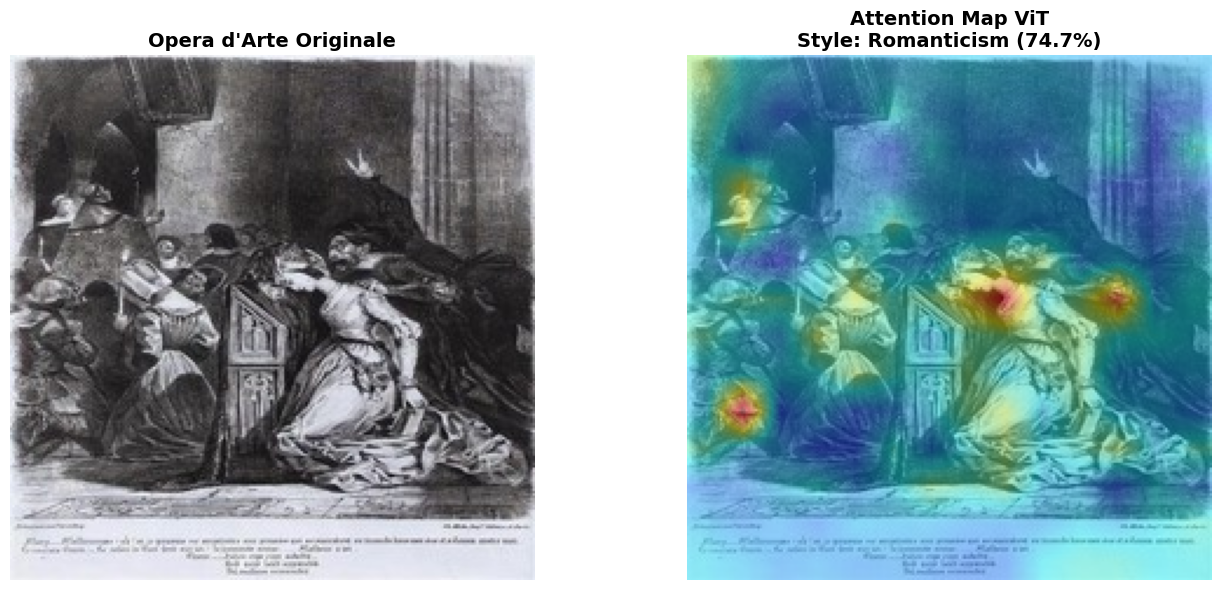

In [18]:
image_size = 224
url = "/kaggle/working/wikiart_balanced/Romanticism/eugene-delacroix_marguerite-in-the-church-with-the-evil-spirits-1828(1).jpg"
print("Il file esiste?", os.path.exists(url))

image = utils.read(url, image_size)
print("Shape immagine caricata:", image.shape)

vit_base_layer = None
for layer in model_vit.layers:
    if isinstance(layer, tf.keras.Model):
        vit_base_layer = layer
        break

assert vit_base_layer is not None and vit_base_layer.name == "vit-b16"


def apply_gradcam(img_array, heatmap):
   
    img = img_array.astype("uint8")
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    return overlay


def compute_vit_attention_heatmap(vit_base, image_uint8):

    size = vit_base.input_shape[1]
    grid_size = int(np.sqrt(vit_base.layers[5].output[0].shape[-2] - 1))

    X = vit.preprocess_inputs(cv2.resize(image_uint8, (size, size)))[np.newaxis, :]

    outputs = [
        l.output[1] for l in vit_base.layers
        if isinstance(l, vit_layers.TransformerBlock)
    ]

    attention_extractor = tf.keras.models.Model(
        inputs=vit_base.inputs,
        outputs=outputs
    )

    weights = np.array(attention_extractor.predict(X, verbose=0))

    num_layers = weights.shape[0]
    num_heads = weights.shape[2]

    reshaped = weights.reshape(
        (num_layers, num_heads, grid_size ** 2 + 1, grid_size ** 2 + 1)
    )

    
    reshaped = reshaped.mean(axis=1)

    v = reshaped[-1]
    for n in range(1, len(reshaped)):
        v = np.matmul(v, reshaped[-1 - n])

    mask = v[0, 1:].reshape(grid_size, grid_size)
    mask = mask / mask.max()
    mask = cv2.resize(mask, (image_uint8.shape[1], image_uint8.shape[0]))

    return mask


heatmap_vit = compute_vit_attention_heatmap(vit_base_layer, image.astype("uint8"))
attention_map_colored = apply_gradcam(image, heatmap_vit)

class_names = [
    "Abstract_Expressionism", "Baroque", "Cubism", "Early_Renaissance",
    "Expressionism", "Impressionism", "Pop_Art", "Romanticism",
    "Symbolism", "Ukiyo_e"
]

preds = model_vit.predict(image[np.newaxis], verbose=0)
predicted_idx = np.argmax(preds[0])
predicted_style = class_names[predicted_idx]
confidence = preds[0][predicted_idx] * 100
print(f'\nPredizione Modello: {predicted_style} ({confidence:.2f}%)')

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 6))
ax1.axis('off'); ax2.axis('off')
ax1.set_title("Opera d'Arte Originale", fontsize=14, fontweight='bold')
ax2.set_title(f'Attention Map ViT\nStyle: {predicted_style} ({confidence:.1f}%)', fontsize=14, fontweight='bold')
ax1.imshow(image)
ax2.imshow(attention_map_colored)
plt.tight_layout()
plt.savefig("/kaggle/working/ViT_AttentionMap.jpg", dpi=300)
plt.show()

**GRAD-CAM ResNet50V2 e DenseNet121**

In [5]:
import json
import keras
import tensorflow as tf
from tensorflow.keras.applications.resnet_v2 import preprocess_input as preprocess_input_resnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_input_densenet

RESNET_DIR = "/kaggle/input/models/emanueladagostino/resnet50/keras/default/1"      
DENSENET_DIR = "/kaggle/input/models/emanueladagostino/dense121/keras/default/1"   

def load_split_model(model_dir, preprocess_fn):
    with open(f"{model_dir}/config.json") as f:
        full_config = json.load(f)
    model = keras.saving.deserialize_keras_object(
        full_config,
        custom_objects={"preprocess_input": preprocess_fn},
        safe_mode=False
    )
    model.load_weights(f"{model_dir}/model.weights.h5")
    return model

model_resnet = load_split_model(RESNET_DIR, preprocess_input_resnet)
model_densenet = load_split_model(DENSENET_DIR, preprocess_input_densenet)
print("Entrambi i modelli caricati correttamente!")

Entrambi i modelli caricati correttamente!


In [6]:
def find_layer_names(model):
    backbone_name = gap_name = dropout_name = dense_hidden = dense_output = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            backbone_name = layer.name
        elif isinstance(layer, tf.keras.layers.GlobalAveragePooling2D):
            gap_name = layer.name
        elif isinstance(layer, tf.keras.layers.Dropout):
            dropout_name = layer.name
        elif isinstance(layer, tf.keras.layers.Dense):
            if dense_hidden is None:
                dense_hidden = layer.name
            else:
                dense_output = layer.name
    return backbone_name, gap_name, dropout_name, dense_hidden, dense_output

resnet_names = find_layer_names(model_resnet)
densenet_names = find_layer_names(model_densenet)
print("ResNet:", resnet_names)
print("DenseNet:", densenet_names)

ResNet: ('resnet50v2', 'global_average_pooling2d', 'dropout', 'dense', 'dense_1')
DenseNet: ('densenet121', 'global_average_pooling2d', 'dropout', 'dense', 'dense_1')


In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam(model, backbone_name, last_conv_layer_name, gap_name, dropout_name, dense_name, output_name, img_array):
    backbone = model.get_layer(backbone_name)
    grad_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[backbone.get_layer(last_conv_layer_name).output, backbone.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array)
        x = model.get_layer(gap_name)(features)
        x = model.get_layer(dropout_name)(x, training=False)
        x = model.get_layer(dense_name)(x)
        predictions = model.get_layer(output_name)(x)
        predicted_class = tf.argmax(predictions[0])
        loss = predictions[:, predicted_class]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)
    if max_value != 0:
        heatmap /= max_value
    return heatmap.numpy()

def apply_gradcam(img_array, heatmap):
    img = img_array.astype("uint8")
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    return overlay

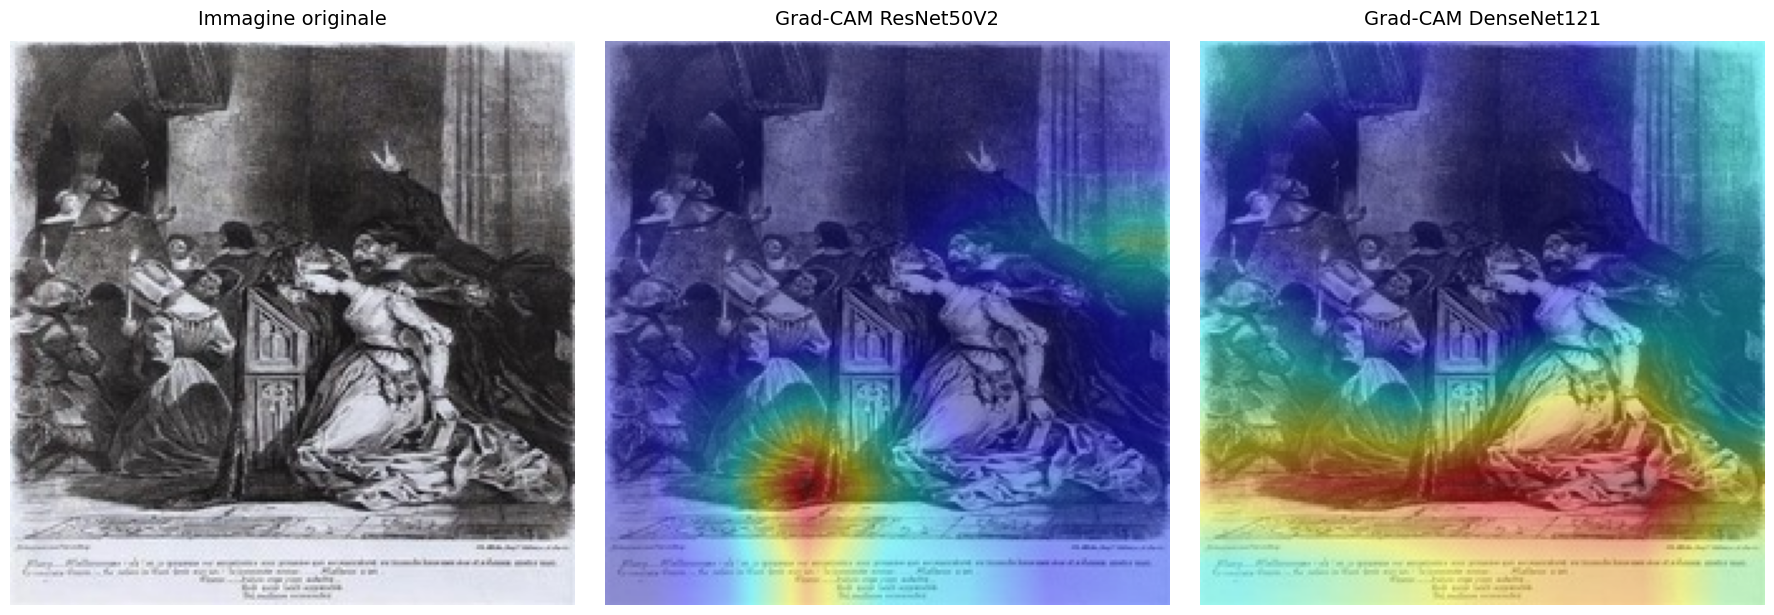

In [16]:
from tensorflow.keras.applications.resnet_v2 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

url = "/kaggle/working/wikiart_balanced/Romanticism/eugene-delacroix_marguerite-in-the-church-with-the-evil-spirits-1828(1).jpg"

img = tf.keras.utils.load_img(url, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
input_img = np.expand_dims(img_array, axis=0)

input_img_resnet = preprocess_resnet(input_img.copy())
input_img_densenet = preprocess_densenet(input_img.copy())

backbone_name_r, gap_name_r, dropout_name_r, dense_hidden_r, dense_output_r = resnet_names
backbone_name_d, gap_name_d, dropout_name_d, dense_hidden_d, dense_output_d = densenet_names

heatmap_resnet = make_gradcam(
    model_resnet,
    backbone_name_r,
    "post_relu", 
    gap_name_r,
    dropout_name_r,
    dense_hidden_r,
    dense_output_r,
    input_img_resnet  
)
gradcam_resnet = apply_gradcam(img_array, heatmap_resnet)

heatmap_dense = make_gradcam(
    model_densenet,
    backbone_name_d,
    "conv5_block16_concat",
    gap_name_d,
    dropout_name_d,
    dense_hidden_d,
    dense_output_d,
    input_img_densenet  
)
gradcam_dense = apply_gradcam(img_array, heatmap_dense)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_array.astype("uint8"))

plt.title("Immagine originale", fontsize=14, pad=12) 
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gradcam_resnet)
plt.title("Grad-CAM ResNet50V2", fontsize=14, pad=12)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gradcam_dense)
plt.title("Grad-CAM DenseNet121", fontsize=14, pad=12)
plt.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/Confronto_GradCAM_ResNet_DenseNet.png", dpi=300, bbox_inches="tight")

**Web application built with Streamlit**

In [ ]:
!pip install streamlit

In [ ]:
!pip install vit-keras opencv-python

In [ ]:
%%writefile app.py

import streamlit as st
import os
import json
import numpy as np
import tensorflow as tf
import keras
import cv2
from PIL import Image
from vit_keras import vit, utils, visualize
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess


st.set_page_config(
    page_title="GuessArt",
    page_icon="🎨",
    layout="wide"
)



st.markdown(
"""
<style>

@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;500;600;700&family=Playfair+Display:wght@600;700&display=swap');

html, body, [class*="css"] {
    font-family: 'Poppins', sans-serif;
}

.stApp {
    background: radial-gradient(circle at 15% 10%, #2b1055 0%, #12071f 45%, #06040d 100%);
    color: #f4f1fb;
}

/* Header */
.hero {
    text-align: center;
    padding: 2.2rem 1rem 1.4rem 1rem;
}

.hero h1 {
    font-family: 'Playfair Display', serif;
    font-size: 3rem;
    background: linear-gradient(90deg, #ffd76a, #ff8fb1, #9d7dff);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom: 0.2rem;
}

.hero p {
    color: #cbbdf0;
    font-size: 1.05rem;
    letter-spacing: 0.03em;
}

/* Upload box */
[data-testid="stFileUploader"] {
    background: rgba(255,255,255,0.04);
    border: 1.5px dashed #9d7dff66;
    border-radius: 18px;
    padding: 1rem;
}

[data-testid="stFileUploader"] label p {
    color: #f4f1fb !important;
    font-weight: 500;
    font-size: 1rem;
}

section[data-testid="stFileUploaderDropzone"] {
    background: rgba(18, 7, 31, 0.55) !important;
    border: 1.5px dashed rgba(157, 125, 255, 0.55) !important;
    border-radius: 14px !important;
}

section[data-testid="stFileUploaderDropzone"] svg {
    fill: #cbbdf0 !important;
}

div[data-testid="stFileUploaderDropzoneInstructions"] span,
div[data-testid="stFileUploaderDropzoneInstructions"] small,
div[data-testid="stFileUploaderDropzoneInstructions"] div {
    color: #e6ddff !important;
}

section[data-testid="stFileUploaderDropzone"] button {
    background: linear-gradient(90deg, #ffd76a, #ff8fb1) !important;
    color: #12071f !important;
    border: none !important;
    border-radius: 999px !important;
    font-weight: 600 !important;
    padding: 0.4rem 1.1rem !important;
}

[data-testid="stFileUploaderFile"] {
    background: rgba(255,255,255,0.06) !important;
    border-radius: 10px !important;
    padding: 4px 8px !important;
}

[data-testid="stFileUploaderFile"] * {
    color: #f4f1fb !important;
}

[data-testid="stFileUploaderFileName"] {
    color: #f4f1fb !important;
}

/* Model cards */
.model-card {
    background: linear-gradient(160deg, rgba(255,255,255,0.07), rgba(255,255,255,0.02));
    border: 1px solid rgba(255,255,255,0.09);
    border-radius: 18px;
    padding: 20px 22px;
    margin-bottom: 18px;
    box-shadow: 0 8px 24px rgba(0,0,0,0.35);
    backdrop-filter: blur(6px);
}

.model-card h4 {
    margin: 0 0 6px 0;
    font-size: 1.15rem;
    color: #ffd76a;
}

.style-pill {
    display: inline-block;
    padding: 5px 14px;
    border-radius: 999px;
    background: linear-gradient(90deg, #9d7dff, #ff8fb1);
    color: #12071f;
    font-weight: 600;
    font-size: 0.95rem;
    margin: 6px 0 10px 0;
}

.conf-bar-bg {
    background: rgba(255,255,255,0.08);
    border-radius: 999px;
    height: 10px;
    width: 100%;
    overflow: hidden;
}

.conf-bar-fill {
    height: 10px;
    border-radius: 999px;
    background: linear-gradient(90deg, #ffd76a, #ff8fb1);
}

.conf-label {
    font-size: 0.85rem;
    color: #cbbdf0;
    margin-top: 4px;
}

.winner-banner {
    text-align: center;
    background: linear-gradient(160deg, rgba(255,215,106,0.16), rgba(157,125,255,0.14));
    border: 1px solid rgba(255,215,106,0.4);
    border-radius: 18px;
    padding: 20px 18px;
    margin: 0 0 1.1rem 0;
    box-shadow: 0 8px 22px rgba(0,0,0,0.3);
}

.winner-tag {
    margin: 0;
    font-size: 0.85rem;
    letter-spacing: 0.08em;
    text-transform: uppercase;
    color: #cbbdf0;
}

.winner-banner h3 {
    margin: 4px 0 8px 0;
    font-family: 'Playfair Display', serif;
    font-size: 1.7rem;
    color: #ffd76a;
}

.winner-sub {
    margin: 0;
    color: #e6ddff;
    font-size: 0.92rem;
}

.waiting-panel {
    background: rgba(255,255,255,0.04);
    border: 1px dashed rgba(255,255,255,0.15);
    border-radius: 16px;
    padding: 22px;
    color: #cbbdf0;
    text-align: center;
    font-size: 0.95rem;
}

.mini-result {
    display: flex;
    justify-content: space-between;
    align-items: center;
    background: rgba(255,255,255,0.05);
    border: 1px solid rgba(255,255,255,0.08);
    border-radius: 12px;
    padding: 10px 16px;
    margin-bottom: 8px;
    font-size: 0.9rem;
}

.mini-style {
    color: #ffd76a;
    font-weight: 500;
}

.mini-conf {
    color: #cbbdf0;
    font-variant-numeric: tabular-nums;
}

.section-gap {
    margin-top: 1.8rem;
    border-top: 1px solid rgba(255,255,255,0.08);
    padding-top: 0.4rem;
}

/* Buttons */
div.stButton > button {
    border-radius: 999px;
    border: 1px solid rgba(255,255,255,0.18);
    background: rgba(255,255,255,0.06);
    color: #f4f1fb;
    font-weight: 500;
    padding: 0.4rem 1.1rem;
    transition: all 0.2s ease;
}

div.stButton > button:hover {
    border-color: #ffd76a;
    color: #ffd76a;
    background: rgba(255,215,106,0.08);
}

div.stButton > button[kind="primary"] {
    background: linear-gradient(90deg, #ffd76a, #ff8fb1);
    color: #12071f;
    border: none;
    font-weight: 700;
}

hr {
    border-color: rgba(255,255,255,0.08);
}

</style>
""",
unsafe_allow_html=True
)



RESNET_DIR = (
    "/kaggle/input/models/"
    "emanueladagostino/resnet50/"
    "keras/default/1"
)

DENSENET_DIR = (
    "/kaggle/input/models/"
    "emanueladagostino/dense121/"
    "keras/default/1"
)

VIT_DIR = (
    "/kaggle/input/models/"
    "emanueladagostino/vitkeras/"
    "keras/default/1"
)


class_names = [
    "Abstract_Expressionism",
    "Baroque",
    "Cubism",
    "Early_Renaissance",
    "Expressionism",
    "Impressionism",
    "Pop_Art",
    "Romanticism",
    "Symbolism",
    "Ukiyo_e"
]

IMG_SIZE = 224


@st.cache_resource
def load_model_folder(model_dir, preprocess_name):

    if preprocess_name == "resnet":
        preprocess = resnet_preprocess
    elif preprocess_name == "densenet":
        preprocess = densenet_preprocess
    elif preprocess_name == "vit":
        preprocess = vit.preprocess_inputs

    with open(f"{model_dir}/config.json") as f:
        full_config = json.load(f)

    model = keras.saving.deserialize_keras_object(
        full_config,
        custom_objects={
            "preprocess_input": preprocess,
            "preprocess_inputs": preprocess
        },
        safe_mode=False
    )

    model.load_weights(f"{model_dir}/model.weights.h5")

    return model


@st.cache_resource
def load_all_models():
    model_resnet = load_model_folder(RESNET_DIR, "resnet")
    model_dense = load_model_folder(DENSENET_DIR, "densenet")
    model_vit = load_model_folder(VIT_DIR, "vit")
    return model_resnet, model_dense, model_vit


with st.spinner("Caricamento modelli..."):
    model_resnet, model_dense, model_vit = load_all_models()


def prepare_image(image):
   
    img = image.convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img).astype("float32")

    raw_batch = np.expand_dims(img_array, axis=0)

    resnet_batch = resnet_preprocess(raw_batch.copy())
    dense_batch = densenet_preprocess(raw_batch.copy())
    vit_batch = vit.preprocess_inputs(raw_batch.copy())

    return img_array, raw_batch, resnet_batch, dense_batch, vit_batch


def find_model_layers(model):
    backbone = None
    gap = None
    dropout = None
    dense_hidden = None
    output = None

    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            backbone = layer.name
        elif isinstance(layer, tf.keras.layers.GlobalAveragePooling2D):
            gap = layer.name
        elif isinstance(layer, tf.keras.layers.Dropout):
            dropout = layer.name
        elif isinstance(layer, tf.keras.layers.Dense):
            if dense_hidden is None:
                dense_hidden = layer.name
            else:
                output = layer.name

    return backbone, gap, dropout, dense_hidden, output


resnet_layers = find_model_layers(model_resnet)
dense_layers = find_model_layers(model_dense)


def make_gradcam(model, backbone_name, last_conv_layer_name, gap_name,
                  dropout_name, dense_name, output_name, image):

    backbone = model.get_layer(backbone_name)

    grad_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[backbone.get_layer(last_conv_layer_name).output, backbone.output]
    )

    with tf.GradientTape() as tape:
        conv_output, features = grad_model(image)
        x = model.get_layer(gap_name)(features)
        x = model.get_layer(dropout_name)(x, training=False)
        x = model.get_layer(dense_name)(x)
        prediction = model.get_layer(output_name)(x)
        class_index = tf.argmax(prediction[0])
        loss = prediction[:, class_index]

    gradients = tape.gradient(loss, conv_output)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    conv_output = conv_output[0]

    heatmap = conv_output @ pooled_gradients[..., None]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)
    if max_value != 0:
        heatmap /= max_value

    return heatmap.numpy()


def apply_gradcam(original, heatmap):
    heatmap = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    result = cv2.addWeighted(original.astype("uint8"), 0.6, heatmap, 0.4, 0)
    return result


def make_attention_map(model, image):
    
    from vit_keras import layers as vit_layers

    vit_base = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            vit_base = layer
            break

    if vit_base is None:
        raise Exception("Backbone ViT non trovato")

    size = vit_base.input_shape[1]
    grid_size = int(np.sqrt(vit_base.layers[5].output[0].shape[-2] - 1))

    X = vit.preprocess_inputs(cv2.resize(image, (size, size)))[np.newaxis, :]

    outputs = [
        l.output[1] for l in vit_base.layers
        if isinstance(l, vit_layers.TransformerBlock)
    ]

    attention_extractor = tf.keras.models.Model(
        inputs=vit_base.inputs,
        outputs=outputs
    )

    weights = np.array(attention_extractor.predict(X, verbose=0))

    num_layers = weights.shape[0]
    num_heads = weights.shape[2]

    reshaped = weights.reshape(
        (num_layers, num_heads, grid_size ** 2 + 1, grid_size ** 2 + 1)
    )

    reshaped = reshaped.mean(axis=1)

    v = reshaped[-1]
    for n in range(1, len(reshaped)):
        v = np.matmul(v, reshaped[-1 - n])

    mask = v[0, 1:].reshape(grid_size, grid_size)
    mask = mask / mask.max()
    mask = cv2.resize(mask, (image.shape[1], image.shape[0]))

    return apply_gradcam(image, mask)


def run_predictions(raw_batch):
    pred_resnet = model_resnet.predict(raw_batch, verbose=0)[0]
    pred_dense = model_dense.predict(raw_batch, verbose=0)[0]
    pred_vit = model_vit.predict(raw_batch, verbose=0)[0]

    results = {
        "ResNet50V2": {
            "style": class_names[int(np.argmax(pred_resnet))],
            "conf": float(np.max(pred_resnet)),
            "icon": "🟠"
        },
        "DenseNet121": {
            "style": class_names[int(np.argmax(pred_dense))],
            "conf": float(np.max(pred_dense)),
            "icon": "🟣"
        },
        "Vision Transformer": {
            "style": class_names[int(np.argmax(pred_vit))],
            "conf": float(np.max(pred_vit)),
            "icon": "🔵"
        }
    }
    return results


def compute_xai(model_key, original, resnet_batch, dense_batch, vit_batch):
    if model_key == "ResNet50V2":
        backbone_r, gap_r, drop_r, dense_r, out_r = resnet_layers
        heatmap_r = make_gradcam(
            model_resnet, backbone_r, "post_relu",
            gap_r, drop_r, dense_r, out_r, resnet_batch
        )
        return apply_gradcam(original, heatmap_r)

    elif model_key == "DenseNet121":
        backbone_d, gap_d, drop_d, dense_d, out_d = dense_layers
        heatmap_d = make_gradcam(
            model_dense, backbone_d, "conv5_block16_concat",
            gap_d, drop_d, dense_d, out_d, dense_batch
        )
        return apply_gradcam(original, heatmap_d)

    elif model_key == "Vision Transformer":
        
        return make_attention_map(model_vit, original.astype("uint8"))


if "uploaded_bytes" not in st.session_state:
    st.session_state.uploaded_bytes = None
if "results" not in st.session_state:
    st.session_state.results = None
if "prepared" not in st.session_state:
    st.session_state.prepared = None
if "xai_visible" not in st.session_state:
    st.session_state.xai_visible = {}
if "xai_cache" not in st.session_state:
    st.session_state.xai_cache = {}
if "uploader_key" not in st.session_state:
    st.session_state.uploader_key = 0


def reset_session():
    st.session_state.uploaded_bytes = None
    st.session_state.results = None
    st.session_state.prepared = None
    st.session_state.xai_visible = {}
    st.session_state.xai_cache = {}
    st.session_state.uploader_key += 1
    st.rerun()



st.markdown(
"""
<div class="hero">
    <h1>🎨GuessArt🎨</h1>
    <p>✨Classificazione degli stili artistici✨</p>
</div>
""",
unsafe_allow_html=True
)

top_left, top_right = st.columns([5, 1])
with top_right:
    if st.button("Clear🗑️", use_container_width=True):
        reset_session()

uploaded_file = st.file_uploader(
    "Carica un dipinto",
    type=["jpg", "jpeg", "png"],
    key=f"uploader_{st.session_state.uploader_key}"
)

if uploaded_file is not None and st.session_state.uploaded_bytes != uploaded_file.getvalue():
    st.session_state.uploaded_bytes = uploaded_file.getvalue()
    st.session_state.results = None
    st.session_state.prepared = None
    st.session_state.xai_visible = {}
    st.session_state.xai_cache = {}

if st.session_state.uploaded_bytes is not None:

    image = Image.open(__import__("io").BytesIO(st.session_state.uploaded_bytes))

    img_col, result_col = st.columns([1, 1], gap="large")

    with img_col:
        st.image(image, caption="Immagine caricata", use_container_width=True)

    with result_col:
        if st.session_state.results is None:
            st.write("")
            st.markdown(
                '<div class="waiting-panel">L\'opera è pronta: avvia l\'analisi per '
                'scoprire lo stile artistico.</div>',
                unsafe_allow_html=True
            )
            st.write("")
            if st.button("Analizza l'opera🔍 ", type="primary", use_container_width=True):
                with st.spinner("Analisi in corso..."):
                    original, raw_batch, resnet_batch, dense_batch, vit_batch = prepare_image(image)
                    st.session_state.prepared = {
                        "original": original,
                        "raw_batch": raw_batch,
                        "resnet_batch": resnet_batch,
                        "dense_batch": dense_batch,
                        "vit_batch": vit_batch
                    }
                    st.session_state.results = run_predictions(raw_batch)
                    st.session_state.xai_visible = {}
                    st.session_state.xai_cache = {}
                    st.rerun()
        else:
            results = st.session_state.results
            winner_key = max(results, key=lambda k: results[k]["conf"])
            winner = results[winner_key]

            st.markdown(
            f"""
            <div class="winner-banner">
                <p class="winner-tag">Stile riconosciuto🏆</p>
                <h3>{winner['style'].replace('_',' ')}</h3>
                <p class="winner-sub">Modello più sicuro: <b>{winner_key}</b> ({winner['conf']*100:.2f}%)</p>
            </div>
            """,
            unsafe_allow_html=True
            )

            for model_key, r in results.items():
                st.markdown(
                f"""
                <div class="mini-result">
                    <span>{r['icon']} {model_key}</span>
                    <span class="mini-style">{r['style'].replace('_',' ')}</span>
                    <span class="mini-conf">{r['conf']*100:.1f}%</span>
                </div>
                """,
                unsafe_allow_html=True
                )

            if st.button("Rianalizza🔄 ", use_container_width=True):
                st.session_state.results = None
                st.session_state.prepared = None
                st.session_state.xai_visible = {}
                st.session_state.xai_cache = {}
                st.rerun()

    if st.session_state.results is not None:

        st.markdown('<div class="section-gap"></div>', unsafe_allow_html=True)
        st.subheader("Dettagli modelli🔍")

        cols = st.columns(3)

        for col, (model_key, r) in zip(cols, results.items()):
            with col:
                st.markdown(
                f"""
                <div class="model-card">
                    <h4>{r['icon']} {model_key}</h4>
                    <div class="style-pill">{r['style'].replace('_',' ')}</div>
                    <div class="conf-bar-bg">
                        <div class="conf-bar-fill" style="width:{r['conf']*100:.1f}%;"></div>
                    </div>
                    <div class="conf-label">Confidenza: {r['conf']*100:.2f}%</div>
                </div>
                """,
                unsafe_allow_html=True
                )

                if st.button(f"Spiegabilità🧠", key=f"xai_btn_{model_key}", use_container_width=True):
                    st.session_state.xai_visible[model_key] = not st.session_state.xai_visible.get(model_key, False)

                if st.session_state.xai_visible.get(model_key, False):
                    with st.spinner("Generazione mappa XAI..."):
                        if model_key not in st.session_state.xai_cache:
                            p = st.session_state.prepared
                            xai_img = compute_xai(
                                model_key,
                                p["original"],
                                p["resnet_batch"],
                                p["dense_batch"],
                                p["vit_batch"]
                            )
                            st.session_state.xai_cache[model_key] = xai_img

                        caption = "Grad-CAM" if model_key != "Vision Transformer" else "Attention Map"
                        st.image(
                            st.session_state.xai_cache[model_key],
                            caption=f"{caption} — {model_key}",
                            use_container_width=True
                        )
else:
    st.info("Carica un'immagine per iniziare l'analisi.")

In [ ]:
!pip install pyngrok --quiet

from pyngrok import ngrok
ngrok.set_auth_token("IL_TUO_TOKEN")

public_url = ngrok.connect(8501) 
print(public_url)

In [ ]:
!streamlit run app.py --server.port 8501